In [31]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import Image
# ========== ЗАГРУЗКА ИЗОБРАЖЕНИЯ ==========
filename = '20231001_160106.jpg'  # Укажите имя вашего файла

Изображение можно описать функцией $f(\xi, \eta)$ двух пространственных координат  
$\xi, \eta$, представляющей интенсивность или яркость изображения в каждой точке $(\xi, \eta)$  
плоскости. Математически задача восстановления изображений, искаженных линейной  
пространственно-инвариантной системой (однородной системой), описывается **инте-  
гральным уравнением Фредгольма I рода типа свертки**:

$$
Af \equiv \int_{-\infty}^{+\infty} \int_{-\infty}^{+\infty} k(x - \xi, y - \eta) f(\xi, \eta) \, d\xi d\eta = g(x, y), \quad -\infty < x, y < +\infty,
\tag{1}
$$

где $g(x, y)$ — искаженное изображение на выходе системы; $f(\xi, \eta)$ — исходное изображе-  
ние на входе системы; $k(x - \xi, y - \eta)$ — импульсная характеристика системы, или функция  
рассеяния точки (ФРТ).

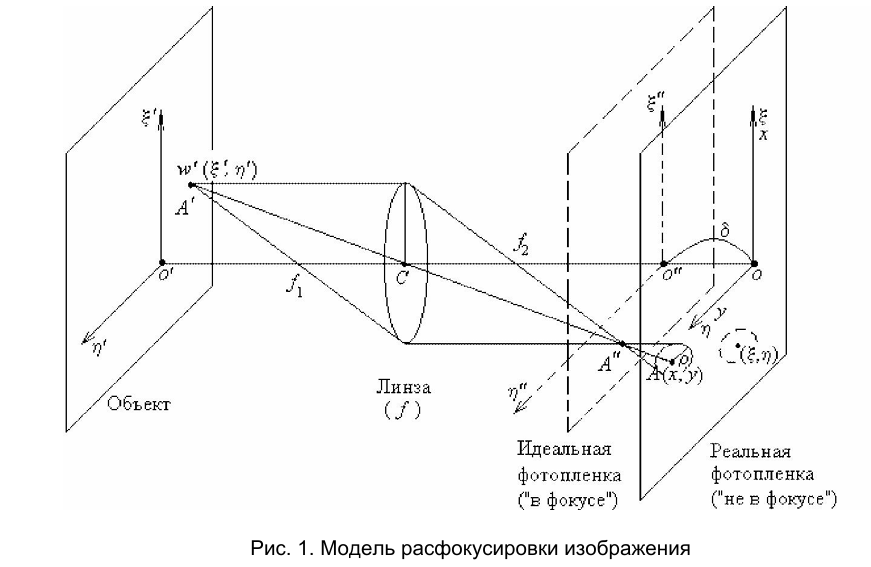

In [32]:
Image('Расфокусировка.png')

Условие накрытия точки \( A(x, y) \) кругом с центром в точке \( (\xi, \eta) \) и радиуса \( \rho \) есть  

$$
\sqrt{(x - \xi)^2 + (y - \eta)^2} \leq \rho,
\tag{4}
$$

в результате интенсивность в точке \( A(x, y) \) будет равна  

$$
g(x, y) = \iint\limits_{\sqrt{(x - \xi)^2 + (y + \eta)^2} \leq \rho} \frac{w(\xi, \eta)}{\pi \rho^2} \, d\xi d\eta.
\tag{5}
$$

Запишем (5) в виде  

$$
\iint\limits_{\sqrt{(x - \xi)^2 + (y + \eta)^2} \leq \rho} \frac{w(\xi, \eta)}{\pi \rho^2} \, d\xi d\eta = g(x, y).
\tag{6}
$$

Соотношение (6) есть **двумерное интегральное уравнение I рода относительно** \( w(\xi, \eta) \) [8–10,15]. Однако оно записано не в стандартной форме. Приведем его к стандартной форме. Запишем (6) в виде  

$$
\int\limits_{-\infty}^{\infty} \int\limits_{-\infty}^{\infty} k(x - \xi, y - \eta) w(\xi, \eta) \, d\xi d\eta = g(x, y), \quad -\infty < x, y < \infty,
$$

где  

$$
k(x - \xi, y - \eta) =
\begin{cases} 
1 / (\pi \rho^2), & \sqrt{(x - \xi)^2 + (y + \eta)^2} \leq \rho, \\
0, & \text{иначе}
\end{cases}
\tag{7}

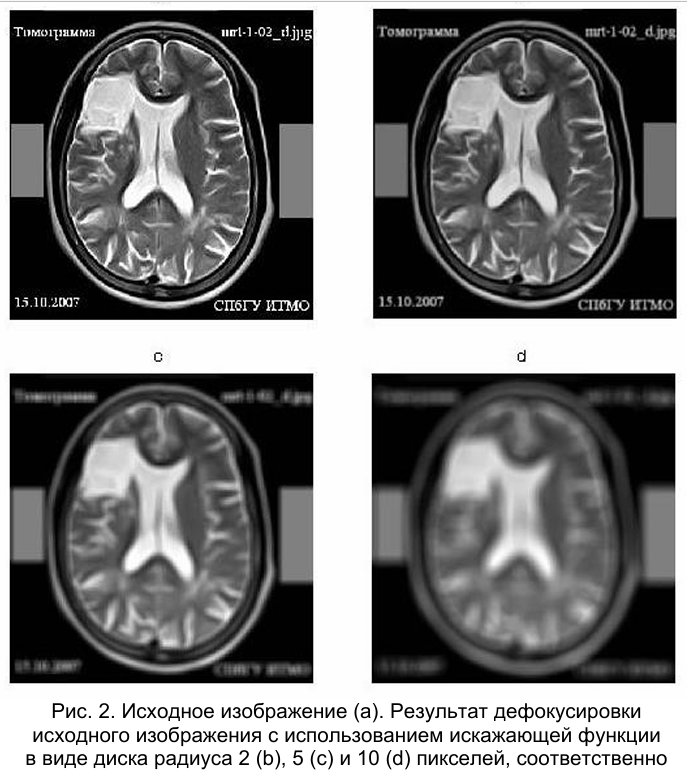

In [33]:
Image('Пример реконструкции изображения.png')

Применительно к нему в методе регуляризации Тихонова решение находится из усло-
вия минимума сглаживающего функционала (10):

$$
\int_{-\infty}^{\infty} \left[ Hw - f(x) \right]^2 dx + \alpha \int_{-\infty}^{\infty} M(\omega) |Y(\omega)|^2 d\omega = \min_W,
\tag{15}
$$

где

$$
M(\omega) = |\omega|^{2q}
\tag{16}
$$

— регуляризатор $q$-го порядка, причем $q \geq 0$ — порядок регуляризации, обычно $q = 1$.

Из условия (15) получается следующее выражение для регуляризованного решения

$$
w_{\alpha}(\xi) = \frac{1}{2\pi} \int_{-\infty}^{\infty} \frac{\lambda(-\omega)F(\omega)}{L(\omega) + \alpha M(\omega)} e^{-i\omega\xi} d\omega,
\tag{17}
$$

где

$$
L(\omega) = |\lambda(\omega)|^2 = \lambda(\omega)\lambda(-\omega) = \operatorname{Re}^2\lambda(\omega) + \operatorname{Im}^2\lambda(\omega).
\tag{18}
$$

Уравнение (1) как двумерное интегральное уравнение Фредгольма I рода типа сверт-
ки может быть решено методом двумерного ПФ (инверсная фильтрация). Решение запи-
сывается в виде ОПФ

$$
w(\xi, \eta) = \frac{1}{4\pi^2} \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} W(\omega_1, \omega_2) e^{-i(\omega_1 \xi + \omega_2 \eta)} d\omega_1 d\omega_2,
\tag{19}
$$

где ПФ (спектр) решения

$$
W(\omega_1, \omega_2) = \frac{G(\omega_1, \omega_2)}{K(\omega_1, \omega_2)},
\tag{20}
$$

где $G(\omega_1, \omega_2)$ и $K(\omega_1, \omega_2)$ — преобразования Фурье (спектры) правой части $g(x, y)$ и ядра
интегрального уравнения (2.21), равные

Устойчивое решение уравнения (1) методами двумерного ПФ и регуляризации Тихонова имеет вид

$$
w_\alpha(\xi, \eta) = \frac{1}{4\pi^2} \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} W_\alpha(\omega_1, \omega_2) e^{-i(\omega_1 \xi + \omega_2 \eta)} d\omega_1 d\omega_2,
\tag{23}
$$

где

$$
W_\alpha(\omega_1, \omega_2) = \frac{K(-\omega_1, -\omega_2) G(\omega_1, \omega_2)}{L(\omega_1, \omega_2) + \alpha M(\omega_1, \omega_2)},
\tag{24}
$$

$$
L(\omega_1, \omega_2) = |K(\omega_1, \omega_2)|^2 = K(\omega_1, \omega_2) K(-\omega_1, -\omega_2),
$$

$$
M(\omega_1, \omega_2) = (\omega_1^2 + \omega_2^2)^2 - \text{регуляризатор}, \quad \alpha > 0 - \text{параметр регуляризации}.
$$

Решение (17)–(18) при правильно выбранных значениях \(\alpha\) и \(\delta\) (или \(\rho\)) обладает устойчивостью и достаточной разрешающей способностью.

In [34]:
# Функция размытия краев
def blur_edge(img, d=31):
    h, w = img.shape[:2]
    img_pad = cv2.copyMakeBorder(img, d, d, d, d, cv2.BORDER_WRAP)
    img_blur = cv2.GaussianBlur(img_pad, (2 * d + 1, 2 * d + 1), -1)[d:-d, d:-d]
    y, x = np.indices((h, w))
    dist = np.dstack([x, w - x - 1, y, h - y - 1]).min(-1)
    w_mask = np.minimum(np.float32(dist) / d, 1.0)
    return img * w_mask + img_blur * (1 - w_mask)

# Ядро смаза (движения)
def motion_kernel(angle, d, sz=65):
    kern = np.ones((1, d), np.float32)
    c, s = np.cos(angle), np.sin(angle)
    A = np.float32([[c, -s, 0], [s, c, 0]])
    sz2 = sz // 2
    A[:, 2] = (sz2, sz2) - np.dot(A[:, :2], ((d - 1) * 0.5, 0))
    kern = cv2.warpAffine(kern, A, (sz, sz), flags=cv2.INTER_CUBIC)
    return kern

# Ядро расфокусировки
def defocus_kernel(d, sz=65):
    kern = np.zeros((sz, sz), np.uint8)
    cv2.circle(kern, (sz, sz), d, 255, -1, cv2.LINE_AA, shift=1)
    kern = np.float32(kern) / 255.0
    return kern

In [35]:
img = cv2.imread(filename, 0)
if img is None:
    raise FileNotFoundError(f"Не удалось загрузить файл: {filename}")

img = np.float32(img) / 255.0
img_original = img.copy()
img = blur_edge(img)

# Предварительное ДПФ изображения
IMG = cv2.dft(img, flags=cv2.DFT_COMPLEX_OUTPUT)

In [42]:
# ========== ПАРАМЕТРЫ ВОССТАНОВЛЕНИЯ ==========
kernel_type = 'defocus'  # 'defocus' или 'motion'
angle = 27           # угол смаза в градусах (только для 'motion')
d = 35                  # размер ядра (радиус расфокусировки или длина смаза)
snr_db = 7             # отношение сигнал/шум в децибелах

# ========== СОЗДАНИЕ И ПРИМЕНЕНИЕ ФИЛЬТРА ==========
noise = 10 ** (-0.1 * snr_db)

# Выбор ядра
if kernel_type == 'defocus':
    psf = defocus_kernel(d)
else:
    ang_rad = np.deg2rad(angle)
    psf = motion_kernel(ang_rad, d)

psf = psf / psf.sum()

# Размещение ядра в padded массиве
psf_pad = np.zeros_like(img)
kh, kw = psf.shape
psf_pad[:kh, :kw] = psf

# ДПФ ядра
PSF = cv2.dft(psf_pad, flags=cv2.DFT_COMPLEX_OUTPUT, nonzeroRows=kh)
PSF2 = (PSF ** 2).sum(-1)

# Инверсный фильтр с регуляризацией
iPSF = PSF / (PSF2 + noise)[..., np.newaxis]
RES = cv2.mulSpectrums(IMG, iPSF, 0)

# Обратное ДПФ
res = cv2.idft(RES, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)
res = np.roll(res, -kh // 2, 0)
res = np.roll(res, -kw // 2, 1)

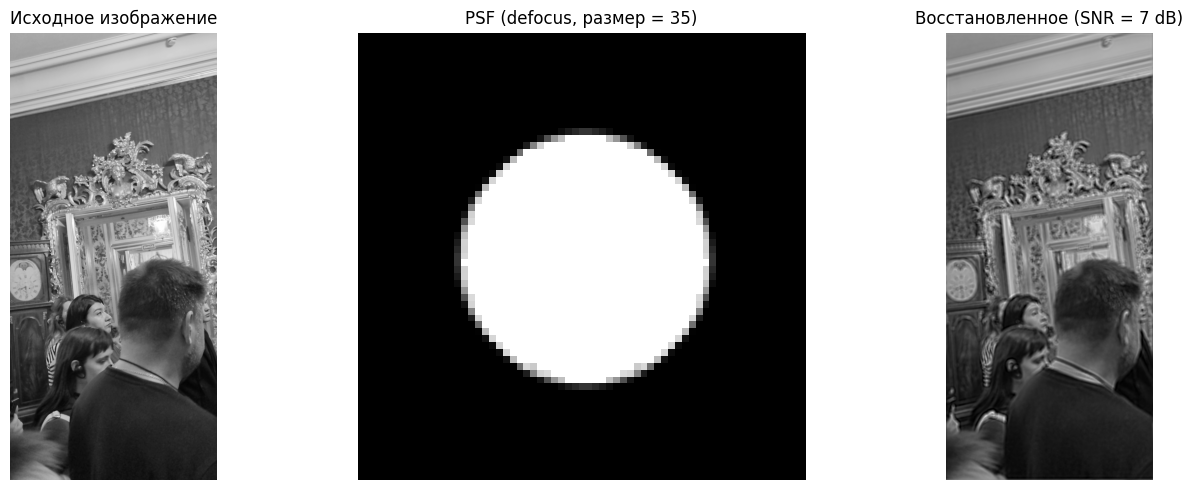

Параметры восстановления:
  Тип ядра: defocus
  Размер ядра (d): 35
  SNR: 7 dB


In [43]:
# ========== ОТОБРАЖЕНИЕ РЕЗУЛЬТАТОВ ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Исходное изображение')
axes[0].axis('off')

axes[1].imshow(psf, cmap='gray')
axes[1].set_title(f'PSF ({kernel_type}, размер = {d})')
axes[1].axis('off')

axes[2].imshow(res, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f'Восстановленное (SNR = {snr_db} dB)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Параметры восстановления:")
print(f"  Тип ядра: {kernel_type}")
print(f"  Размер ядра (d): {d}")
if kernel_type == 'motion':
    print(f"  Угол смаза: {angle}°")
print(f"  SNR: {snr_db} dB")